In [6]:
!pip install tensorflow tensorflow_hub matplotlib pillow

KeyboardInterrupt: 

In [7]:
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [1]:
from google.colab import files
uploaded = files.upload()

Saving church.jpg to church.jpg
Saving style.jpg to style.jpg


In [3]:
def load_image(path):
    img = Image.open(path)
    img = img.convert("RGB")
    img = img.resize((512, 512))
    img = np.array(img) / 255.0
    img = img[np.newaxis, :]
    return tf.convert_to_tensor(img, dtype=tf.float32)

In [8]:
content_image = load_image("church.jpg")
style_image = load_image("style.jpg")

In [9]:
model = hub.load(
    "https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2"
)

In [10]:
stylized_image = model(tf.constant(content_image), tf.constant(style_image))[0]

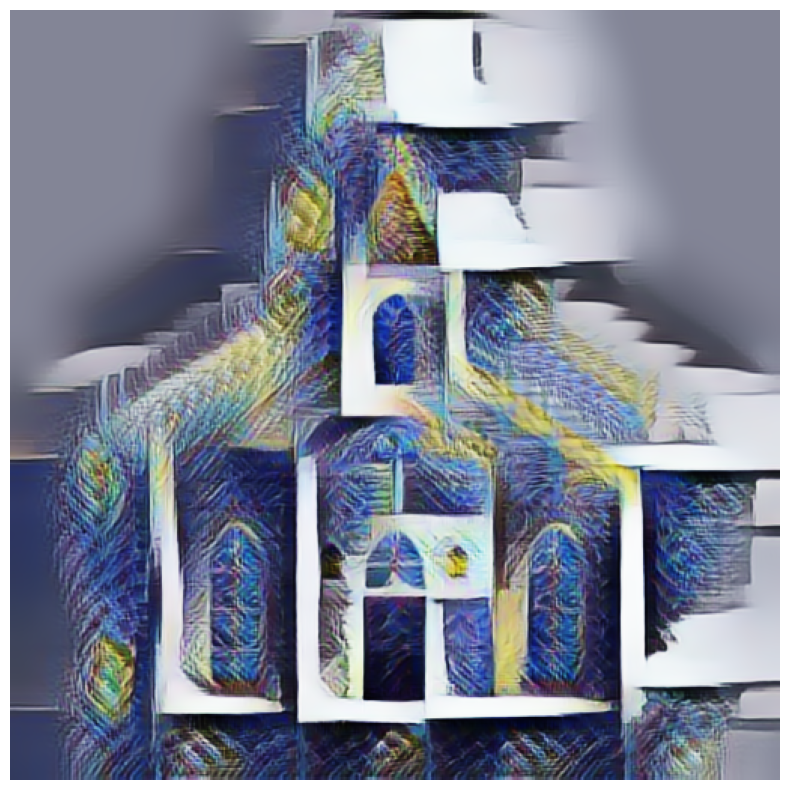

In [11]:
plt.figure(figsize=(10,10))
plt.imshow(tf.squeeze(stylized_image))
plt.axis("off")
plt.show()

In [12]:
output = tf.squeeze(stylized_image)
output = Image.fromarray((output.numpy() * 255).astype(np.uint8))
output.save("stylized_output.jpg")

In [13]:
from google.colab import files

files.download("stylized_output.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>